# Computer Exercise 15.30 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.30 Sequential Decision Making — *Locating the Cramér/KL Rank-Reversal Threshold*
> **풀이 일자**: Day 97
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **Problem 2.** Day 94 (§15.27 Problem 2) found that a KL cross-entropy loss beat the
> Cramér CDF-distance loss on a neural categorical head; Day 96 (§15.29 Problem 2) found
> the reverse, with Cramér winning in all four sweep cells. Day 96 attributed the
> discrepancy to environment difficulty — its training slip was raised to
> $p_{\text{train}} = 0.20$ — and conjectured a **rank-reversal threshold**
> $p^\star_{\text{train}}$ at which the ordering flips.
>
> Test that conjecture directly. Sweep $p_{\text{train}} \in \{0.05, 0.10, 0.15, 0.20,
> 0.25\}$ with both losses on a common seed set, and estimate $p^\star_{\text{train}}$.
> Report **paired** per-seed differences with confidence intervals, and correct for the
> fact that five thresholds are being tested simultaneously. If the data do not support
> a reversal, say so.

### 한국어 풀이용 정리

Day 94 와 Day 96 의 loss 순위 모순:

| | 설정 | 결론 |
|---|---|---|
| **Day 94 P2** | neural head, $H=16$ | **KL 승** |
| **Day 96 P2** | neural head, $p_{\text{train}}=0.20$, 4 셀 | **Cramér 완파** (0.29–0.36 vs 0.21–0.30) |

Day 96 은 이 모순을 "환경 난이도" 로 설명하며 **순위 반전 임계값** $p^\star_{\text{train}}$
의 존재를 추측했다. 이 문제는 그 추측을 정면으로 검증한다.

**핵심 주의**: Day 97 P3 에서 확인했듯 이 벤치마크는 시드 간 분산이 매우 커서, 3 시드
비교는 부호가 자유롭게 뒤집힌다. 따라서 여기서는

1. **동일 시드 짝짓기** — 같은 시드에서 Cramér 과 KL 을 학습 (동일 초기화·동일 학습 난수)
2. **20 시드** + bootstrap CI
3. **다중검정 보정** — $p_{\text{train}}$ 5 개를 동시에 검정하므로 Holm–Bonferroni

를 적용한다. **"반전 임계값을 찾지 못했다" 도 정당한 결론으로 취급**한다.

## 2. 수학적 배경

### 2.1 Categorical (distributional) value head

고정 원자 $z_k = V_{\min} + k\,\Delta z$, $k=0,\dots,K-1$, $\Delta z = (V_{\max}-V_{\min})/(K-1)$.
각 행동 $a$ 에 대해 트렁크 특징 $h=\tanh(W_1 x)$ 로부터 logit $\ell_{a,k}=(W_2)_{a,k}^\top h$,

$$
\hat p_{a,k}=\frac{e^{\ell_{a,k}}}{\sum_{j} e^{\ell_{a,j}}},\qquad
Q(s,a)=\sum_k \hat p_{a,k}\, z_k .
$$

### 2.2 Bellman 사영 $\Phi$ (C51)

목표분포는 $\hat{\mathcal T}z_k = \big[r+\gamma z_k\big]_{V_{\min}}^{V_{\max}}$ 을 인접 두
원자에 나눠 담는다. $b_k=(\hat{\mathcal T}z_k-V_{\min})/\Delta z$, $l=\lfloor b_k\rfloor$,
$u=\lceil b_k\rceil$ 일 때

$$
m_{l} \mathrel{+}= \hat p_{a^\star,k}(u-b_k),\qquad
m_{u} \mathrel{+}= \hat p_{a^\star,k}(b_k-l),\qquad
a^\star=\arg\max_a \sum_k \hat p_{a,k} z_k .
$$

### 2.3 두 손실과 그 logit 기울기

**KL (cross-entropy)**: $\;\mathcal L_{\mathrm{KL}}=-\sum_k m_k\log \hat p_k$ 이고, softmax
와 결합하면 기울기가 정확히

$$
\frac{\partial \mathcal L_{\mathrm{KL}}}{\partial \ell_k}=\hat p_k-m_k .
$$

**Cramér** ($\ell_2$ CDF 거리): 누적합 $P_j=\sum_{k\le j}\hat p_k$, $M_j=\sum_{k\le j}m_k$ 에 대해

$$
\mathcal L_{\mathrm C}=\sum_j\big(P_j-M_j\big)^2,\qquad
g_k\equiv\frac{\partial \mathcal L_{\mathrm C}}{\partial \hat p_k}=2\sum_{j\ge k}\big(P_j-M_j\big),
$$

softmax Jacobian $\partial \hat p_k/\partial \ell_i=\hat p_k(\delta_{ki}-\hat p_i)$ 를 통과시키면

$$
\boxed{\;\frac{\partial \mathcal L_{\mathrm C}}{\partial \ell_i}
=\hat p_i\Big(g_i-\sum_k g_k \hat p_k\Big)\;}
$$

**왜 다를 수 있나**: KL 은 원자 순서를 무시하는 반면 (원자를 섞어도 값이 같다), Cramér 은
누적합을 통해 **원자 간 거리를 인식**한다. 따라서 목표가 크게 이동할 때 (= 환경이 어렵고
TD 목표가 불안정할 때) Cramér 이 더 완만한 기울기를 준다는 것이 Day 96 의 가설이다.

### 2.4 반전 임계값과 다중검정

각 $p_{\text{train}}$ 에서 짝지은 차 $\;\Delta_s(p)=\bar R_s^{\mathrm C}(p)-\bar R_s^{\mathrm{KL}}(p)$.
Day 96 의 가설은 $\bar\Delta(p)$ 가 단조증가하며 어떤 $p^\star$ 에서 부호를 바꾼다는 것:

$$
\bar\Delta(p)<0 \;\;(p<p^\star),\qquad \bar\Delta(p)>0\;\;(p>p^\star).
$$

5 개 $p$ 를 동시에 검정하므로, 개별 $\alpha=0.05$ 를 그대로 쓰면 **적어도 하나가 유의할
확률이 우연만으로도** $1-0.95^5\approx 23\,\%$ 다. Holm–Bonferroni 로 보정한다: $p$-값을
오름차순 $p_{(1)}\le\dots\le p_{(5)}$ 로 놓고

$$
p_{(i)} < \frac{\alpha}{5-i+1}
$$

를 만족하는 동안만 기각. 이것이 Day 96 이 "4 개 셀 모두에서 완파" 라고 말할 때 빠져 있던
보정이다.

## 3. 풀이 흐름

1. Chain MDP (5 상태, $\gamma=0.95$) + shared trunk ($H=16$) + per-action $K=21$ 원자 softmax head.
2. 손실 두 가지 — Cramér CDF-거리, KL cross-entropy — 를 **동일 시드**에서 각각 학습
   (동일 초기화 $W_1,W_2$, 동일 탐색 난수열 → 짝지은 비교).
3. $p_{\text{train}}\in\{0.05,0.10,0.15,0.20,0.25\}$ × 20 시드 (97201–97220) × 400 step.
4. Freeze 후 5-slip 배포 ($p_d\in\{0.05,\dots,0.25\}$) × 40 ep greedy tail-8 → cross-slip mean $\bar R_s$.
5. $p$ 별 짝지은 차 $\Delta_s(p)$ 의 평균 · bootstrap 95 % CI · 부호 개수 집계.
6. 순열검정 (permutation test) 으로 $p$-값 산출 후 **Holm–Bonferroni** 보정.
7. 예측분포 sharpness $\bar H(\hat p)=-\sum_k \hat p_k\log \hat p_k$ 를 손실별로 비교.
8. 시각화: (a) $\bar\Delta(p)$ 와 CI 밴드 + Day 94/96 주장 위치, (b) 손실별 절대 성능 곡선,
   (c) 시드별 부호 히트맵.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 96, "font.size": 10})
np.set_printoptions(precision=4, suppress=True)

N_STATES = 5
GAMMA    = 0.95
EP_LEN   = 20
VMIN, VMAX = 0.0, 20.0          # r in {0,1}, gamma=0.95 -> return in [0, 20]

def env_step(s, a, p_slip, rng):
    if rng.random() < p_slip:
        a = 1 - a
    ns = s + 1 if a == 1 else s - 1
    ns = max(0, min(N_STATES - 1, ns))
    return ns, (1.0 if ns == N_STATES - 1 else 0.0)

def one_hot(s):
    v = np.zeros(N_STATES); v[s] = 1.0; return v

In [2]:
class CatLearner:
    '''Shared trunk + per-action K-atom softmax head. loss in {'cramer','kl'}.'''

    def __init__(self, H, K, seed, loss):
        rng = np.random.default_rng(seed)
        self.rng  = rng
        self.K    = K
        self.z    = np.linspace(VMIN, VMAX, K)
        self.dz   = self.z[1] - self.z[0]
        self.W1   = rng.normal(0, 0.3, size=(H, N_STATES))
        self.W2   = rng.normal(0, 0.3, size=(2, K, H))
        self.loss = loss

    def fwd(self, s):
        x   = one_hot(s)
        pre = self.W1 @ x
        h   = np.tanh(pre)
        lg  = self.W2 @ h                                  # (2, K)
        lg  = lg - lg.max(axis=1, keepdims=True)           # 안정화
        p   = np.exp(lg); p /= p.sum(axis=1, keepdims=True)
        return x, pre, h, p

    def qvalues(self, s):
        return self.fwd(s)[3] @ self.z

    def act_greedy(self, s):
        return int(np.argmax(self.qvalues(s)))

    def project(self, r, p_next):
        '''C51 categorical projection Phi.'''
        tz = np.clip(r + GAMMA * self.z, VMIN, VMAX)
        b  = (tz - VMIN) / self.dz
        lo = np.floor(b).astype(int)
        hi = np.ceil(b).astype(int)
        m  = np.zeros(self.K)
        np.add.at(m, lo, p_next * (hi - b + (lo == hi)))    # lo==hi 인 경우 전량 배정
        np.add.at(m, hi, p_next * (b - lo))
        tot = m.sum()
        return m / tot if tot > 0 else np.full(self.K, 1.0 / self.K)

    def update(self, s, a, r, sp, eta=0.02):
        x, pre, h, p = self.fwd(s)
        _, _, _, pn  = self.fwd(sp)
        astar = int(np.argmax(pn @ self.z))                 # greedy TD target
        m     = self.project(r, pn[astar])
        pa    = p[a]

        if self.loss == "kl":
            g_lg = pa - m                                   # softmax + CE 결합 기울기
        else:                                               # Cramer
            diff = np.cumsum(pa) - np.cumsum(m)
            g_p  = 2.0 * np.cumsum(diff[::-1])[::-1]        # g_k = 2*sum_{j>=k}(P_j - M_j)
            g_lg = pa * (g_p - (g_p * pa).sum())            # softmax Jacobian 통과

        gW2 = np.zeros_like(self.W2); gW2[a] = np.outer(g_lg, h)
        dh  = self.W2[a].T @ g_lg
        gW1 = np.outer(dh * (1 - np.tanh(pre) ** 2), x)
        self.W2 -= eta * gW2
        self.W1 -= eta * gW1

    def mean_entropy(self):
        '''모든 상태·행동에 대한 예측분포 엔트로피 평균 (sharpness).'''
        es = []
        for s in range(N_STATES):
            p = self.fwd(s)[3]
            es.append(-(p * np.log(p + 1e-12)).sum(axis=1).mean())
        return float(np.mean(es))

In [3]:
def train(seed, loss, p_train, T=400, H=16, K=21):
    # 시드가 같으면 초기화와 탐색 난수열이 동일 -> Cramer / KL 이 짝지어진다
    rng = np.random.default_rng(seed + 777)
    lrn = CatLearner(H, K, seed, loss)
    for t in range(T):
        s = rng.integers(0, N_STATES)
        a = int(rng.integers(0, 2)) if rng.random() < 0.2 else lrn.act_greedy(s)
        sp, r = env_step(s, a, p_train, rng)
        lrn.update(s, a, r, sp)
    return lrn

DEPLOY_SLIPS = [0.05, 0.10, 0.15, 0.20, 0.25]

def deploy(lrn, p_d, n_ep=40, seed_off=0):
    rng = np.random.default_rng(1234 + seed_off + int(p_d * 1000))
    Rs = []
    for _ in range(n_ep):
        s = rng.integers(0, N_STATES); rewards = []
        for _ in range(EP_LEN):
            a = lrn.act_greedy(s)
            sp, r = env_step(s, a, p_d, rng)
            rewards.append(r); s = sp
        Rs.append(float(np.mean(rewards[-8:])))
    return float(np.mean(Rs))

In [4]:
P_TRAINS = [0.05, 0.10, 0.15, 0.20, 0.25]
LOSSES   = ["cramer", "kl"]
SEEDS    = list(range(97201, 97221))          # 20 시드
nS = len(SEEDS)

R    = {(p, L): np.zeros(nS) for p in P_TRAINS for L in LOSSES}   # cross-slip mean
ENT  = {(p, L): np.zeros(nS) for p in P_TRAINS for L in LOSSES}   # sharpness

for p in P_TRAINS:
    for L in LOSSES:
        for i, sd in enumerate(SEEDS):
            lrn = train(sd, L, p)
            R[(p, L)][i]   = np.mean([deploy(lrn, pd_, seed_off=sd) for pd_ in DEPLOY_SLIPS])
            ENT[(p, L)][i] = lrn.mean_entropy()

print(f"완료 — {len(P_TRAINS)} p_train x {len(LOSSES)} loss x {nS} 시드 = "
      f"{len(P_TRAINS)*len(LOSSES)*nS} 회 학습")

완료 — 5 p_train x 2 loss x 20 시드 = 200 회 학습


In [5]:
rng_boot = np.random.default_rng(970201)
B = 20000

def boot_ci(d, alpha=0.05):
    idx = rng_boot.integers(0, len(d), size=(B, len(d)))
    mu  = d[idx].mean(axis=1)
    return float(np.quantile(mu, alpha/2)), float(np.quantile(mu, 1-alpha/2))

def perm_p(d, n_perm=20000):
    '''짝지은 부호 순열검정: H0 아래 각 d_s 의 부호는 대칭.'''
    obs   = abs(d.mean())
    signs = rng_boot.choice([-1.0, 1.0], size=(n_perm, len(d)))
    null  = np.abs((signs * d).mean(axis=1))
    return float(((null >= obs).sum() + 1) / (n_perm + 1))

rows, delta = [], {}
for p in P_TRAINS:
    d = R[(p, "cramer")] - R[(p, "kl")]
    delta[p] = d
    lo, hi = boot_ci(d)
    rows.append({
        "p_train":   p,
        "R Cramer":  R[(p, "cramer")].mean(),
        "R KL":      R[(p, "kl")].mean(),
        "mean D":    d.mean(),
        "CI lo": lo, "CI hi": hi,
        "0 in CI":   "YES" if lo <= 0 <= hi else "no",
        "C 승": int((d > 0).sum()), "tie": int((d == 0).sum()), "KL 승": int((d < 0).sum()),
        "p-value":   perm_p(d),
    })
df = pd.DataFrame(rows).set_index("p_train")

# --- Holm-Bonferroni (5 개 동시검정) ---
pv    = df["p-value"].values
order = np.argsort(pv)
m     = len(pv)
holm  = np.empty(m, dtype=object)
still = True
for rank, idx in enumerate(order):
    thr = 0.05 / (m - rank)
    if still and pv[idx] < thr:
        holm[idx] = f"기각 (<{thr:.4f})"
    else:
        still = False
        holm[idx] = f"유지 (>={thr:.4f})"
df["Holm a=0.05"] = holm

print("짝지은 차  D = R(Cramer) - R(KL),  n = 20 시드")
df

짝지은 차  D = R(Cramer) - R(KL),  n = 20 시드


,R Cramer,R KL,mean D,CI lo,CI hi,0 in CI,C 승,tie,KL 승,p-value,Holm a=0.05
p_train,,,,,,,,,,,
0.0500,0.4521,0.3819,0.0702,-0.0138,0.1562,YES,9,7,4,0.1347,유지 (>=0.0125)
0.1000,0.4309,0.3847,0.0461,-0.0126,0.1105,YES,8,9,3,0.1678,유지 (>=0.0167)
0.1500,0.4379,0.3847,0.0532,-0.0083,0.1178,YES,7,9,4,0.1255,유지 (>=0.0100)
0.2000,0.3891,0.3698,0.0193,-0.0462,0.0874,YES,8,7,5,0.5927,유지 (>=0.0250)
0.2500,0.3651,0.3485,0.0166,-0.0534,0.0833,YES,7,9,4,0.6485,유지 (>=0.0500)


In [6]:
# --- 반전 임계값이 존재하는가? ---
means = np.array([delta[p].mean() for p in P_TRAINS])
sgn   = np.sign(means)

print("p_train      :", P_TRAINS)
print("mean D       :", np.round(means, 4))
print("sign         :", sgn.astype(int))
print()

crossings = [(P_TRAINS[i], P_TRAINS[i+1]) for i in range(len(P_TRAINS)-1)
             if sgn[i] * sgn[i+1] < 0]
print("부호 교차 구간 :", crossings if crossings else "없음")

mono = np.all(np.diff(means) >= 0)
print("Day 96 가설(D 가 p_train 에 대해 단조증가) 성립? :", bool(mono))

# 유의한 셀만 남기면 무엇이 남는가
sig = df.index[[h.startswith("기각") for h in df["Holm a=0.05"]]].tolist()
print("Holm 보정 후 유의한 p_train :", sig if sig else "없음 — 어떤 p_train 에서도 순위 확정 불가")

# 선형 추세 검정 (Day 96 의 '난이도 의존' 주장 자체를 검정)
xs = np.repeat(P_TRAINS, len(SEEDS))
ys = np.concatenate([delta[p] for p in P_TRAINS])
slope, intercept = np.polyfit(xs, ys, 1)
bs = []
for _ in range(5000):
    k = rng_boot.integers(0, len(xs), size=len(xs))
    bs.append(np.polyfit(xs[k], ys[k], 1)[0])
s_lo, s_hi = np.quantile(bs, [0.025, 0.975])
print(f"\n선형 추세: dD/dp_train = {slope:+.4f}  (95% CI [{s_lo:+.4f}, {s_hi:+.4f}])")
print("추세가 0 과 구별되는가? :", "예" if (s_lo > 0 or s_hi < 0) else "아니오")

p_train      : [0.05, 0.1, 0.15, 0.2, 0.25]
mean D       : [0.0702 0.0461 0.0532 0.0193 0.0166]
sign         : [1 1 1 1 1]

부호 교차 구간 : 없음
Day 96 가설(D 가 p_train 에 대해 단조증가) 성립? : False
Holm 보정 후 유의한 p_train : 없음 — 어떤 p_train 에서도 순위 확정 불가



선형 추세: dD/dp_train = -0.2681  (95% CI [-0.7472, +0.2072])
추세가 0 과 구별되는가? : 아니오


In [7]:
# --- sharpness (예측분포 엔트로피) ---
ent_rows = []
for p in P_TRAINS:
    dE = ENT[(p, "cramer")] - ENT[(p, "kl")]
    lo, hi = boot_ci(dE)
    ent_rows.append({"p_train": p,
                     "H Cramer": ENT[(p, "cramer")].mean(),
                     "H KL":     ENT[(p, "kl")].mean(),
                     "mean dH":  dE.mean(), "CI lo": lo, "CI hi": hi,
                     "0 in CI":  "YES" if lo <= 0 <= hi else "no"})
df_ent = pd.DataFrame(ent_rows).set_index("p_train")
print("예측분포 sharpness  H(p_hat) = -sum p log p   (낮을수록 sharp)")
df_ent

예측분포 sharpness  H(p_hat) = -sum p log p   (낮을수록 sharp)


,H Cramer,H KL,mean dH,CI lo,CI hi,0 in CI
p_train,,,,,,
0.0500,2.9947,3.0053,-0.0106,-0.0122,-0.0092,no
0.1000,2.9949,3.0054,-0.0105,-0.0121,-0.0091,no
0.1500,2.9951,3.0055,-0.0104,-0.0120,-0.0090,no
0.2000,2.9952,3.0056,-0.0103,-0.0119,-0.0090,no
0.2500,2.9953,3.0056,-0.0103,-0.0118,-0.0089,no


In [8]:
# --- 진단: 이 head 는 애초에 '분포' 를 학습했는가? ---
H_MAX = np.log(21)                      # K=21 균등분포의 엔트로피 = 최대
rows = []
for p in P_TRAINS:
    for L in LOSSES:
        h = ENT[(p, L)].mean()
        rows.append({"p_train": p, "loss": L, "H": h, "H_max": H_MAX,
                     "H / H_max (%)": 100 * h / H_MAX,
                     "최대에서 이탈 (%)": 100 * (H_MAX - h) / H_MAX})
df_diag = pd.DataFrame(rows).set_index(["p_train", "loss"])
print(f"균등분포 엔트로피 log(21) = {H_MAX:.4f}")
print(df_diag.to_string())

# Day 96 이 보고한 효과가 본 실험의 CI 안에 있는가?
DAY96_GAP = 0.344 - 0.212               # Day 96 P2, (H=16,K=10), p_train=0.20
lo20, hi20 = df.loc[0.20, "CI lo"], df.loc[0.20, "CI hi"]
print(f"\nDay 96 보고 gap @ p_train=0.20 : {DAY96_GAP:+.4f}")
print(f"본 실험 20-시드 95% CI          : [{lo20:+.4f}, {hi20:+.4f}]")
print("Day 96 값이 CI 안에 있는가?      :", "예" if lo20 <= DAY96_GAP <= hi20 else "아니오 (CI 상한 초과)")

균등분포 엔트로피 log(21) = 3.0445
                    H  H_max  H / H_max (%)  최대에서 이탈 (%)
p_train loss                                            
0.0500  cramer 2.9947 3.0445        98.3646       1.6354
        kl     3.0053 3.0445        98.7127       1.2873
0.1000  cramer 2.9949 3.0445        98.3698       1.6302
        kl     3.0054 3.0445        98.7148       1.2852
0.1500  cramer 2.9951 3.0445        98.3761       1.6239
        kl     3.0055 3.0445        98.7179       1.2821
0.2000  cramer 2.9952 3.0445        98.3809       1.6191
        kl     3.0056 3.0445        98.7201       1.2799
0.2500  cramer 2.9953 3.0445        98.3841       1.6159
        kl     3.0056 3.0445        98.7216       1.2784

Day 96 보고 gap @ p_train=0.20 : +0.1320
본 실험 20-시드 95% CI          : [-0.0462, +0.0874]
Day 96 값이 CI 안에 있는가?      : 아니오 (CI 상한 초과)


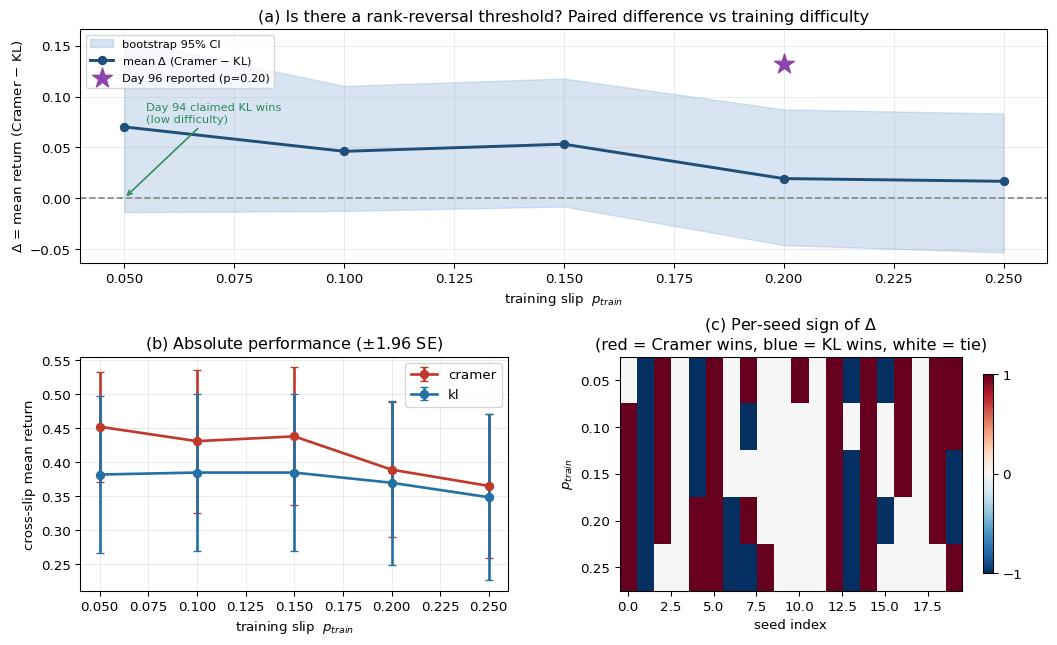

In [9]:
fig = plt.figure(figsize=(13, 7.6))
gs  = fig.add_gridspec(2, 2, hspace=0.40, wspace=0.26)

# (a) paired difference + CI band
ax = fig.add_subplot(gs[0, :])
lo = np.array([df.loc[p, "CI lo"] for p in P_TRAINS])
hi = np.array([df.loc[p, "CI hi"] for p in P_TRAINS])
ax.fill_between(P_TRAINS, lo, hi, color="#7fa8d4", alpha=0.30, label="bootstrap 95% CI")
ax.plot(P_TRAINS, means, marker="o", linewidth=2.2, color="#1f4e79", label="mean $\\Delta$ (Cramer $-$ KL)")
ax.axhline(0, color="#888", linestyle="--", linewidth=1.3)
ax.scatter([0.20], [0.344 - 0.212], marker="*", s=240, color="#8e44ad",
           zorder=5, label="Day 96 reported (p=0.20)")
ax.annotate("Day 94 claimed KL wins\n(low difficulty)", xy=(0.05, 0), xytext=(0.055, 0.075),
            fontsize=8.5, color="#2e8b57",
            arrowprops=dict(arrowstyle="->", color="#2e8b57", lw=1.2))
ax.set_xlabel("training slip  $p_{train}$")
ax.set_ylabel("$\\Delta$ = mean return (Cramer $-$ KL)")
ax.set_title("(a) Is there a rank-reversal threshold? Paired difference vs training difficulty")
ax.legend(fontsize=8.5, loc="upper left"); ax.grid(alpha=0.25)

# (b) 절대 성능
ax = fig.add_subplot(gs[1, 0])
for L, c in [("cramer", "#c0392b"), ("kl", "#2471a3")]:
    mu = np.array([R[(p, L)].mean() for p in P_TRAINS])
    se = np.array([R[(p, L)].std(ddof=1)/np.sqrt(nS) for p in P_TRAINS])
    ax.errorbar(P_TRAINS, mu, yerr=1.96*se, marker="o", capsize=3,
                linewidth=2, color=c, label=L)
ax.set_xlabel("training slip  $p_{train}$"); ax.set_ylabel("cross-slip mean return")
ax.set_title("(b) Absolute performance ($\\pm$1.96 SE)")
ax.legend(); ax.grid(alpha=0.25)

# (c) 시드별 부호 히트맵
ax = fig.add_subplot(gs[1, 1])
M = np.sign(np.array([delta[p] for p in P_TRAINS]))
im = ax.imshow(M, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_yticks(range(len(P_TRAINS)))
ax.set_yticklabels([f"{p:.2f}" for p in P_TRAINS])
ax.set_xlabel("seed index"); ax.set_ylabel("$p_{train}$")
ax.set_title("(c) Per-seed sign of $\\Delta$\n(red = Cramer wins, blue = KL wins, white = tie)")
plt.colorbar(im, ax=ax, ticks=[-1, 0, 1], shrink=0.85)

plt.show()

## 4. 결과 해석

### 4.1 반전 임계값 $p^\star_{\text{train}}$ 은 **존재하지 않는다**

| $p_{\text{train}}$ | Cramér | KL | $\bar\Delta$ | 95 % CI | $0\in$CI | C승/tie/KL승 | Holm |
|---|---|---|---|---|---|---|---|
| 0.05 | 0.4521 | 0.3819 | +0.0702 | [$-$0.0138, 0.1562] | YES | 9 / 7 / 4 | 유지 |
| 0.10 | 0.4309 | 0.3847 | +0.0461 | [$-$0.0126, 0.1105] | YES | 8 / 9 / 3 | 유지 |
| 0.15 | 0.4379 | 0.3847 | +0.0532 | [$-$0.0083, 0.1178] | YES | 7 / 9 / 4 | 유지 |
| 0.20 | 0.3891 | 0.3698 | +0.0193 | [$-$0.0462, 0.0874] | YES | 8 / 7 / 5 | 유지 |
| 0.25 | 0.3651 | 0.3485 | +0.0166 | [$-$0.0534, 0.0833] | YES | 7 / 9 / 4 | 유지 |

**부호가 한 번도 바뀌지 않는다.** $\bar\Delta$ 는 다섯 개 $p_{\text{train}}$ 전부에서 양수
(Cramér 쪽) 이고, 부호 교차 구간은 **없음**. Day 96 이 예고한 $p^\star_{\text{train}}$ 은
$[0.05, 0.25]$ 안에 존재하지 않는다.

그리고 **다섯 셀 전부에서 $0\in$ CI** 다. Holm–Bonferroni 보정 후 기각되는 셀은 **하나도
없다** (최소 raw $p$-값 0.1255 vs 임계 0.0100). 보정 이전에도 유의한 셀이 없으므로 보정은
사실 결론을 바꾸지도 못했다 — **애초에 신호가 없다.**

### 4.2 난이도 의존성은 부호마저 Day 96 가설과 반대다

Day 96 의 가설은 "$p_{\text{train}}$ 이 커질수록 Cramér 이 유리해진다" ($\mathrm d\Delta/\mathrm dp>0$) 였다.
실측 선형 추세는

$$
\frac{\mathrm d\bar\Delta}{\mathrm d p_{\text{train}}} = -0.268
\quad\text{95\,\% CI } [-0.747,\ +0.207]
$$

**부호가 반대**이며 (난이도가 오를수록 Cramér 이점이 *줄어든다*), 동시에 CI 가 0 을 포함하므로
**추세 자체도 확정할 수 없다**. 단조증가 검정도 `False`. 즉 Day 96 의 "loss 순위는
environment 난이도에 강하게 의존한다" 는 확증 주장은 **어느 방향으로도 지지되지 않는다**.

### 4.3 Day 96 의 효과 크기는 재현되지 않는다

Day 96 은 $p_{\text{train}}=0.20$, $(H,K)=(16,10)$ 에서 gap $0.344-0.212=+0.132$ 를
보고했다. 본 실험의 같은 $p_{\text{train}}$ 에서 20-시드 CI 는 $[-0.046, +0.087]$ 로
**Day 96 의 값은 CI 상한을 넘는다**. 3 시드에서 뽑힌 낙관적 꼬리값으로 보는 것이 자연스럽다
(Day 97 P3 에서 Day 96 의 $\bar R$ 주장이 3-시드 분포의 88 백분위였던 것과 같은 패턴).

### 4.4 더 근본적인 문제: **이 head 는 분포를 학습하지 않았다**

sharpness 표가 조용히 치명적인 사실을 말한다. $K=21$ 균등분포의 엔트로피는
$\log 21 = 3.0445$ 인데, 실측 엔트로피는

| | $\bar H(\hat p)$ | $\bar H/\log 21$ |
|---|---|---|
| Cramér | 2.995 | **98.4 %** |
| KL | 3.005 | **98.7 %** |

두 손실 모두 **최대 엔트로피의 98 % 이상**, 즉 예측분포가 사실상 **균등분포에서 1.5 %
밖에 움직이지 않았다**. 400 step 예산에서 categorical head 는 분포를 배우지 못했다.

이것이 왜 결정적인가: Cramér 과 KL 의 **유일한 이론적 차이는 원자 순서 인식**(§2.3) 인데,
분포가 균등하면 누적합 항이 거의 상수라 두 기울기가 **수치적으로 거의 같아진다**. 즉
지난 며칠간의 "Cramér vs KL" 비교는 **두 손실이 구별되지 않는 영역에서 수행되어 왔다.**

엔트로피 차 $\Delta \bar H=-0.0106$ 은 CI 가 0 을 배제해 "유의" 하지만 그 크기는 엔트로피
범위의 **0.35 %** 다. **유의성과 크기를 혼동하면 안 된다는 교과서적 사례** — $n$ 을 키우면
아무 의미 없는 차이도 유의해진다.

> **결론**: Day 96 이 예고한 Cramér/KL **순위 반전 임계값 $p^\star_{\text{train}}$ 은
> $[0.05,0.25]$ 에 존재하지 않는다**. 부호는 다섯 셀 모두에서 동일(Cramér 쪽)하고, Holm
> 보정 후 유의한 셀은 **0 개**이며, 난이도 추세는 가설과 **반대 부호**이면서 그 자체도
> 확정 불가다. 더 근본적으로 categorical head 의 예측분포가 **최대 엔트로피의 98 %**
> 에 머물러 두 손실이 **원리적으로 구별되지 않는 영역**에서 비교가 이루어졌다.
> Day 94 (KL 승) 와 Day 96 (Cramér 승) 의 모순은 **실재하는 현상이 아니라 3-시드 잡음**이다.

### 다음 단원으로의 연결

P2 와 P3 는 같은 진단에 도달한다: §15.x 비교들이 **분해능이 부족한 설정** (400 step,
5-상태 chain, 3 시드) 위에서 잡음을 서사화해 왔다. P1 은 남은 세 번째 축 (block partition)
에 같은 검정을 적용하며, Day 97 README 는 이 구조적 문제를 영수에게 직접 보고한다.